# Module 7 · Take-Home Lab — Reusable Skills & Prompt Optimization
## Instruction packs loaded on demand, A/B tested, and improved from measured results

---

### Where this sits

| | Take-home lab | What it covers |
|---|---|---|
| | **Context Window Management** | context management — what *leaves* the window |
| **you are here** | **Reusable Skills** | skills — what is allowed *in*, and how to prove it helps |

**A note on the scenario.** Unlike its companion take-home, this lab steps away from ShopSmart. Skills are a general technique, so it uses a separate enterprise scenario — TechNova Solutions, with three genuinely different domains — to keep the idea clean.

Read the two Module 7 take-homes as a matched pair: **context management decides what leaves the window, skills decide what is allowed in.** Section 8 below is where the two meet.

---

### How to work through this lab

| | Sections | Roughly |
|---|---|---|
| **Core** | 1 – 7 — skills, the two loading strategies, the A/B test, the judge, and the optimization loop | ~90 min |
| **Deep dive** | 8 – 11 — the `SKILL.md` open standard, honest A/B statistics, automated prompt optimization, and the production checklist | at your own pace |

Start with the core. The deep-dive sections are what turn this notebook from a demonstration into code you can lift into a real project — work through them afterwards.

Build **reusable skill packs** — specialized instruction sets that an agent loads on-demand based on query classification. Then **A/B test** the skill-based agent against a generic one, and **iteratively optimize** the weakest skill using LLM-as-Judge feedback.

## Business Scenario: TechNova Solutions — Enterprise AI Assistant

**TechNova Solutions** is a mid-size Indian enterprise handling three distinct workflows: insurance claims processing, customer support, and regulatory compliance. Their single AI assistant struggles:

1. **Quality Varies Wildly (2.9-4.2/5):** One generic prompt tries to handle 3 very different domains. Claims processing scores 4.2/5, support 3.8/5, but compliance review only 2.9/5 — barely usable.

2. **Prompt Maintenance Nightmare (2 hrs/week):** Domain experts spend 2 hours weekly updating prompts scattered across 15 config files. Changes break other domains because everything shares one giant prompt.

3. **No Testing Discipline (\"Prompt YOLO\"):** Prompt changes go live without testing. Last month, a well-intentioned tweak to the claims prompt caused 300 compliance reviews to get wrong instructions.

4. **Token Waste (\u20b94,200/day):** Loading all 3 domain instructions (2000 tokens) every turn when only 1 domain is needed (600 tokens). At 500 queries/day, that's \u20b94,200/day in wasted tokens.

**Our Solution:** Modular skills (specialized instruction packs) loaded on-demand. A/B test each skill systematically. Iteratively optimize based on measured results.

> 🏠 **Take-home reference lab.** Not run in the workshop sessions — work through it afterwards at your own pace. Its API keys are yours to create (see the workshop's `README.md`).

In [1]:
# 📦 Packages this notebook needs. On the workshop VM they are pre-installed from
# the workshop's requirements.txt, so the install line below stays commented out.
# Running somewhere else (Colab, your own laptop)? Uncomment it and run this cell once.
# !pip install -qU langchain langchain-openai langchain-anthropic python-dotenv

from importlib.metadata import PackageNotFoundError, version

NOTEBOOK_PACKAGES = [
    "langchain",
    "langchain-openai",
    "langchain-anthropic",
    "python-dotenv",
]
for package_name in NOTEBOOK_PACKAGES:
    try:
        print(f"{package_name:<26} {version(package_name)}")
    except PackageNotFoundError:
        print(f"{package_name:<26} NOT INSTALLED — uncomment the !pip line above")

langchain                  1.4.3
langchain-openai           1.6.6
langchain-anthropic        1.7.5
python-dotenv              1.2.3


In [2]:
import os

# Where to create each key. The trainer supplies OPENAI_API_KEY on the workshop VM;
# you create any other key yourself and add it to the workshop's .env file as KEY_NAME=value.
KEY_SIGNUP_PAGES = {
    "OPENAI_API_KEY": "supplied on the workshop VM (elsewhere: https://platform.openai.com/api-keys)",
    "TAVILY_API_KEY": "https://app.tavily.com (free tier)",
    "GROQ_API_KEY": "https://console.groq.com/keys (free tier)",
    "WEATHER_API_KEY": "https://www.weatherapi.com/signup.aspx (free tier)",
    "LANGSMITH_API_KEY": "https://smith.langchain.com -> Settings -> API Keys (free tier)",
    "ANTHROPIC_API_KEY": "https://console.anthropic.com/settings/keys",
    "GEMINI_API_KEY": "https://aistudio.google.com/app/apikey",
}


def load_keys(required):
    """Load API keys from Colab Secrets (on Colab) or a local .env file (elsewhere).

    Prints one line per key, then stops with instructions if a required key is missing.

    Args:
        required: the environment-variable names this lab needs.
    """
    try:
        from google.colab import userdata          # running on Google Colab
        for key_name in required:
            try:
                os.environ[key_name] = userdata.get(key_name)
            except Exception:
                pass                                 # not set in Colab Secrets
        source = "Colab Secrets"
    except ImportError:                              # the workshop VM, or any local machine
        from dotenv import find_dotenv, load_dotenv
        load_dotenv(find_dotenv(usecwd=True))        # searches upward for the workshop's .env file
        source = ".env / environment"
    print(f"\U0001F511 Key source: {source}")
    for key_name in required:
        print(f"   {key_name:<22} {'✅' if os.environ.get(key_name) else '❌ MISSING'}")
    missing_keys = [key_name for key_name in required if not os.environ.get(key_name)]
    if missing_keys:
        instructions = "\n".join(
            f"  {key_name}: {KEY_SIGNUP_PAGES.get(key_name, 'see README.md in the workshop folder')}"
            for key_name in missing_keys)
        raise RuntimeError(
            "This lab needs API keys that are not set yet. Create each one, add it to\n"
            "the workshop's .env file as KEY_NAME=value, then re-run this cell:\n" + instructions)


# Two providers, deliberately: the agent under test runs on OpenAI and the LLM-as-Judge
# runs on Anthropic. Section 6 explains why a judge must never share a model family with
# the system it grades.
load_keys(["OPENAI_API_KEY", "ANTHROPIC_API_KEY"])

🔑 Key source: .env / environment
   OPENAI_API_KEY         ✅
   ANTHROPIC_API_KEY      ✅


In [3]:
# --- Imports ---
import copy
import json
import statistics
from pathlib import Path

from langchain_anthropic import ChatAnthropic
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI



In [4]:

# --- Models ---
# chat_model  = the system under test (every skill agent and the generic baseline)
# judge_model = the grader, from a DIFFERENT model family on purpose
chat_model = ChatOpenAI(model="gpt-4.1-mini", temperature=0.3)
judge_model = ChatAnthropic(model="claude-haiku-4-5", temperature=0)

print("Imports loaded.")
print("  System under test: gpt-4.1-mini (temp=0.3)")
print("  LLM-as-Judge:      claude-haiku-4-5 — different family, on purpose")

Imports loaded.
  System under test: gpt-4.1-mini (temp=0.3)
  LLM-as-Judge:      claude-haiku-4-5 — different family, on purpose


## 1. What Are Skills? Reusable Instruction Packs

A **skill** is a self-contained instruction set for a specific domain. Instead of one giant system prompt that covers everything poorly, the agent loads **only the relevant skill** for the current task. Think of it as progressive disclosure — load information on-demand, not upfront.

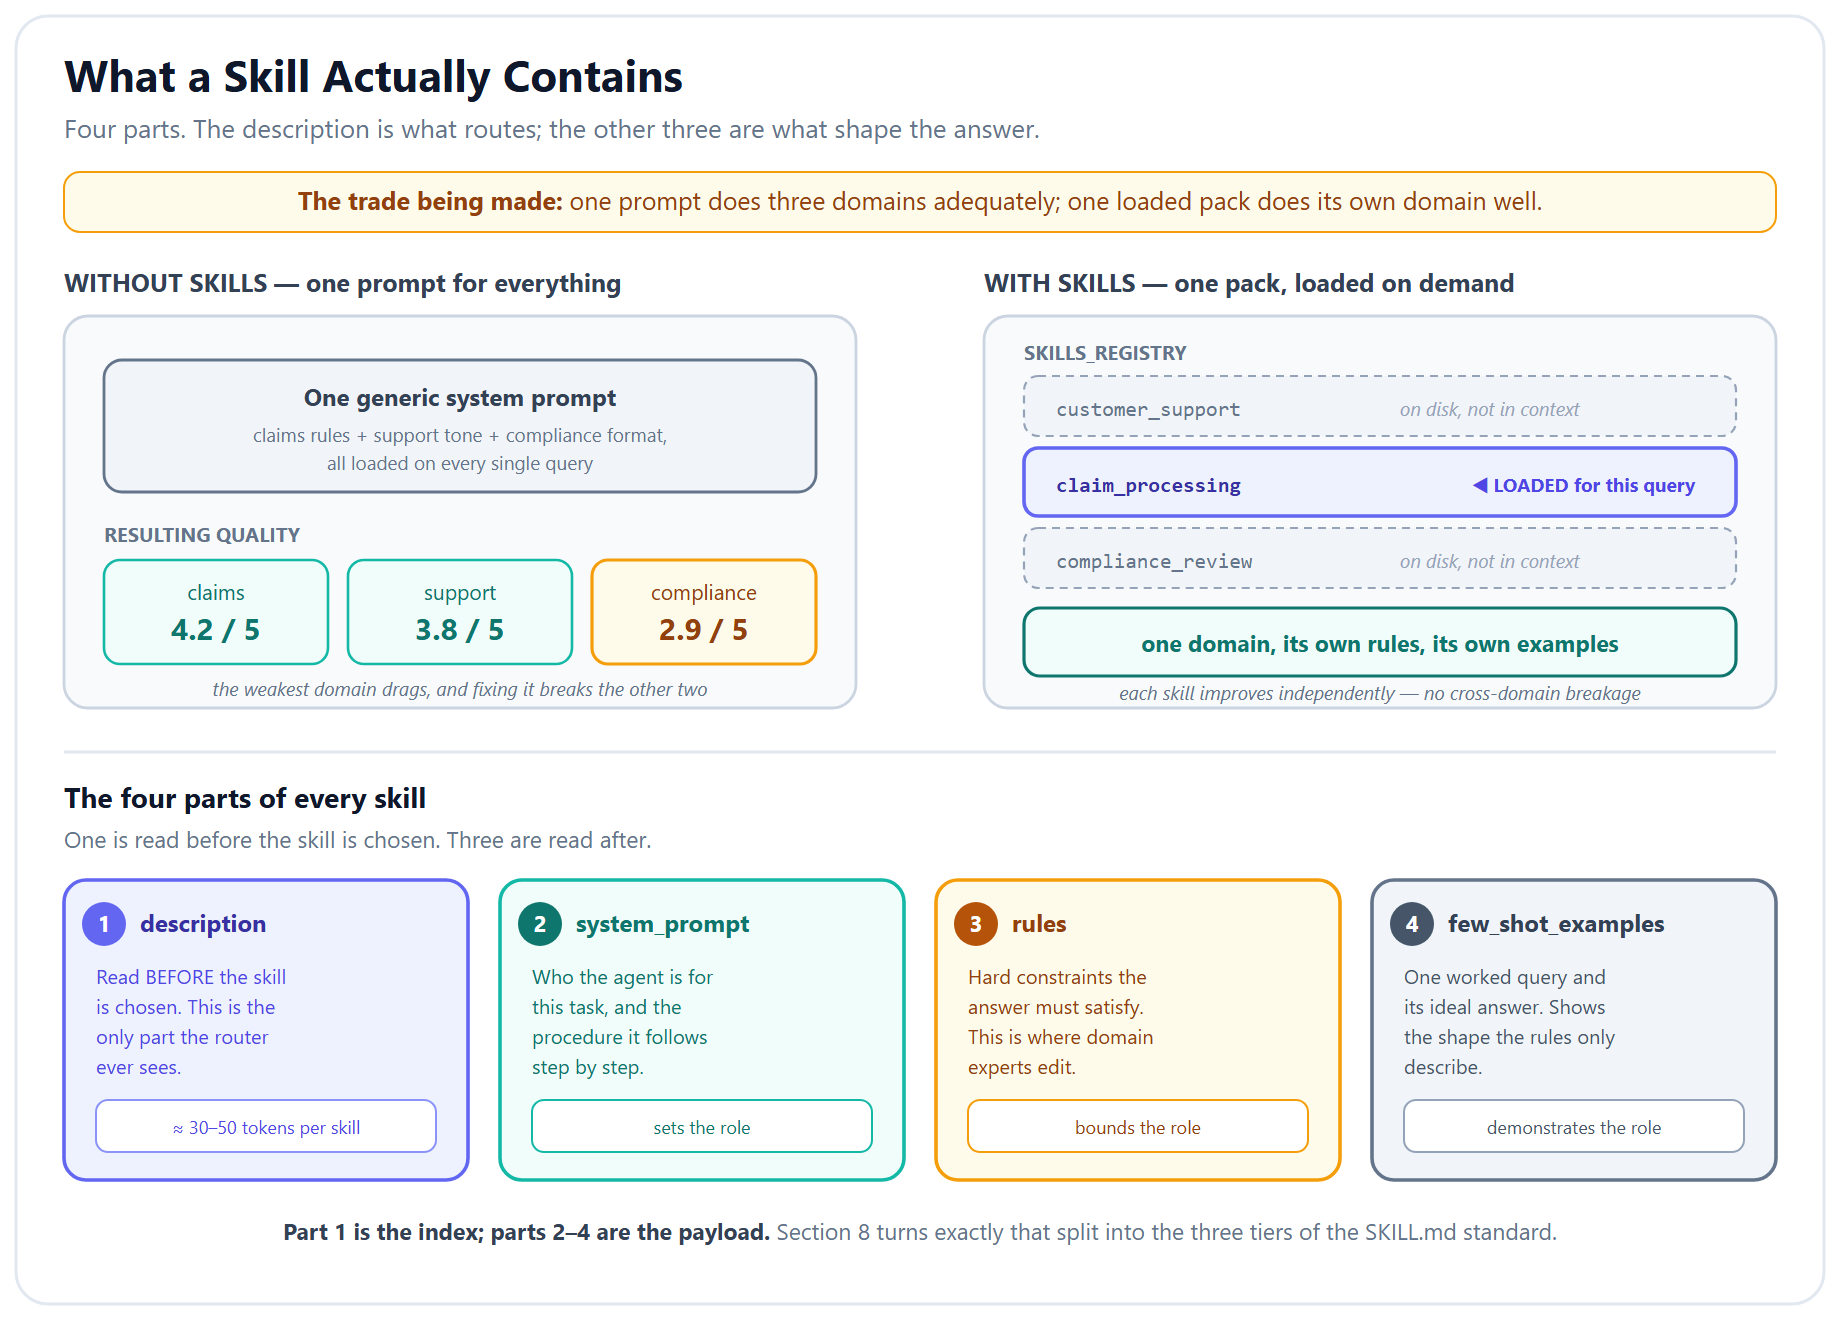

**Figure — What a skill actually contains.** Four parts: a `description` the router reads, a `system_prompt` that sets the role, `rules` that constrain it, and `few_shot_examples` that show the shape of a good answer. The generic agent gets one prompt covering all three domains and does each of them adequately; the skill agent loads one pack and does that one well.

In [5]:
# --- Define 3 Skills as Python Dictionaries ---
# Each skill has: name, description, system_prompt, rules, few_shot_examples

SKILLS_REGISTRY = {
    "claim_processing": {
        "name": "Insurance Claims Processing",
        "description": "Process and evaluate insurance claims following IRDAI guidelines",
        "system_prompt": (
            "You are TechNova's Claims Processing Specialist. You evaluate insurance claims "
            "following IRDAI (Insurance Regulatory and Development Authority of India) guidelines.\n\n"
            "When processing a claim:\n"
            "1. Verify all required documents are mentioned (policy number, incident date, claim amount)\n"
            "2. Check for fraud indicators (inconsistent dates, inflated amounts, repeated claims)\n"
            "3. Apply threshold rules: Auto-approve below \u20b950,000; escalate above \u20b95,00,000\n"
            "4. Provide a clear recommendation: APPROVE / DENY / ESCALATE with reasoning"
        ),
        "rules": (
            "- ALWAYS mention the policy number in your response\n"
            "- Claims older than 90 days require manager review\n"
            "- Water damage claims need photos as supporting evidence\n"
            "- Never approve claims without incident date verification"
        ),
        "few_shot_examples": [
            {
                "query": "Claim for \u20b945,000 by Rajesh Kumar, policy INS-2024-789, water damage to electronics on 15 March 2026.",
                "response": "Claim Review for Policy INS-2024-789:\n- Amount: \u20b945,000 (within auto-approval threshold)\n- Type: Water damage to electronics\n- Date: 15 March 2026 (within 90-day window)\n- Required: Please confirm supporting photos of water damage are on file.\nRecommendation: CONDITIONAL APPROVE pending photo verification."
            }
        ]
    },

    "customer_support": {
        "name": "Customer Support",
        "description": "Handle customer queries, complaints, and service requests",
        "system_prompt": (
            "You are TechNova's Customer Support Specialist. You handle customer queries "
            "with empathy, efficiency, and adherence to SLA commitments.\n\n"
            "SLA Commitments:\n"
            "- P1 (Critical): Respond within 4 hours, resolve within 24 hours\n"
            "- P2 (Standard): Respond within 24 hours, resolve within 72 hours\n"
            "- P3 (Low): Respond within 48 hours, resolve within 1 week\n\n"
            "Escalation triggers: Customer waiting >48 hours, repeated contacts (3+), "
            "explicit request for manager, mentions of legal action."
        ),
        "rules": (
            "- ALWAYS acknowledge the customer's frustration before offering solutions\n"
            "- Provide specific SLA timelines, don't say 'soon'\n"
            "- Offer compensation for SLA breaches (\u20b9500 credit or priority handling)\n"
            "- Never blame the customer; use 'we' language"
        ),
        "few_shot_examples": [
            {
                "query": "I've been waiting 3 days for a response about my policy renewal. This is unacceptable.",
                "response": "I sincerely apologize for the delay, and I understand your frustration. A 3-day wait exceeds our P2 SLA of 24-hour response time. Here's what I'm doing right now:\n1. Escalating your renewal to our priority queue\n2. Applying a \u20b9500 service credit to your account\n3. You will receive an update within 4 hours\nIs there anything else I can help with?"
            }
        ]
    },

    "compliance_review": {
        "name": "Regulatory Compliance Review",
        "description": "Review processes and documents for IRDAI regulatory compliance",
        "system_prompt": (
            "You are TechNova's Compliance Review Specialist. You audit processes and documents "
            "for compliance with IRDAI regulations and internal policies.\n\n"
            "Compliance Framework:\n"
            "1. Document Completeness: All required forms present and filled\n"
            "2. Data Accuracy: Policyholder data matches records\n"
            "3. Timeline Compliance: Processing within regulatory deadlines (30 days for claims)\n"
            "4. Audit Trail: Every decision documented with reason and approver"
        ),
        "rules": (
            "- ALWAYS reference specific IRDAI regulation numbers when citing rules\n"
            "- Flag any missing documentation explicitly\n"
            "- Use severity levels: CRITICAL / HIGH / MEDIUM / LOW for findings\n"
            "- Include recommended remediation for each finding"
        ),
        "few_shot_examples": [
            {
                "query": "Review compliance status of claim batch BT-2026-Q1.",
                "response": "Compliance Review: Batch BT-2026-Q1\n\nFindings:\n1. [CRITICAL] 3 of 50 claims missing incident date documentation (IRDAI Regulation 17.2)\n2. [HIGH] 8 claims processed beyond 30-day deadline (IRDAI Regulation 14.1)\n3. [MEDIUM] 12 claims lack digital signature on approval form\n\nRemediation:\n- Immediately return 3 incomplete claims for documentation\n- File delay justification for 8 overdue claims\n- Implement digital signature workflow by next quarter"
            }
        ]
    }
}

print(f"Skills registry: {len(SKILLS_REGISTRY)} skills")
for name, skill in SKILLS_REGISTRY.items():
    tokens = len(skill['system_prompt'].split()) * 1.3  # Rough token estimate
    print(f"  {name}: ~{int(tokens)} tokens")

Skills registry: 3 skills
  claim_processing: ~91 tokens
  customer_support: ~91 tokens
  compliance_review: ~75 tokens


In [6]:
# --- Token comparison: All skills vs. single skill ---
all_skills_text = "\n\n".join([skill["system_prompt"] + "\n" + skill["rules"] for skill in SKILLS_REGISTRY.values()])
single_skill_text = SKILLS_REGISTRY["claim_processing"]["system_prompt"] + "\n" + SKILLS_REGISTRY["claim_processing"]["rules"]

print(f"All 3 skills combined: ~{len(all_skills_text.split())} words")
print(f"Single skill loaded: ~{len(single_skill_text.split())} words")
print(f"Savings per query: ~{(1 - len(single_skill_text.split())/len(all_skills_text.split()))*100:.0f}% fewer tokens")

All 3 skills combined: ~305 words
Single skill loaded: ~105 words
Savings per query: ~66% fewer tokens


## 2. Loading Strategy A — the Agent Calls a `load_skill` Tool

The agent has a `load_skill` tool. When a query arrives, the agent **decides** which skill to load and calls the tool. The skill instructions flow into the conversation as a tool result.

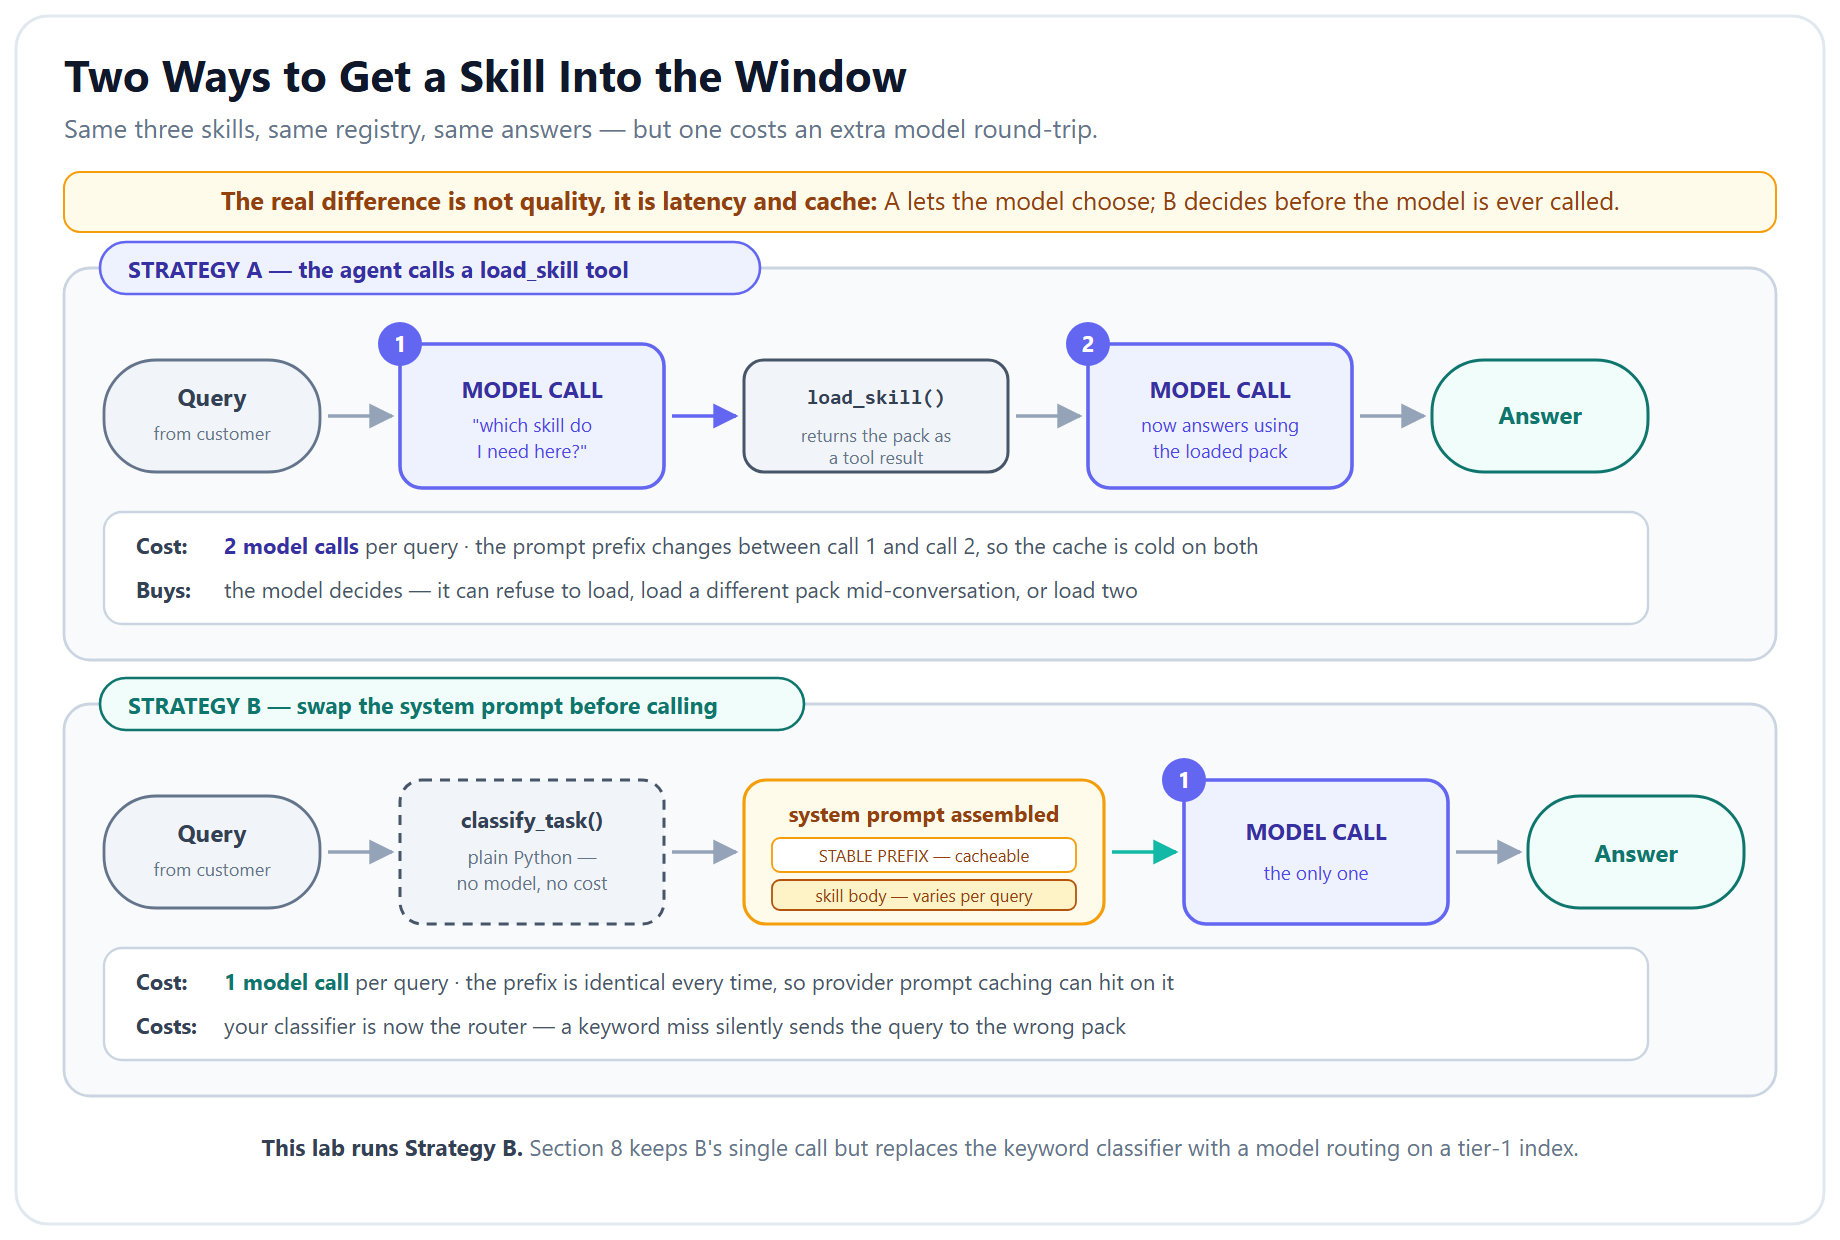

**Figure — Two ways to get a skill into the window.** Strategy A costs an extra model round-trip: the agent must first decide to call `load_skill`, receive the tool result, then answer. Strategy B classifies first and injects the skill straight into the system prompt — one call instead of two, and the stable prefix stays cacheable. A buys autonomy; B buys latency and cache hits.

In [7]:
# --- Approach 1: Tool-Based Skill Loading ---
# The agent calls load_skill() as its first action, then follows the loaded instructions

def load_skill(skill_name: str) -> str:
    """Load a specialized skill for the current task."""
    skill = SKILLS_REGISTRY.get(skill_name)
    if not skill:
        return f"Unknown skill: {skill_name}. Available: {list(SKILLS_REGISTRY.keys())}"
    examples_text = "\n".join([
        f"Example Query: {example['query']}\nExample Response: {example['response']}"
        for example in skill["few_shot_examples"]
    ])
    return (
        f"SKILL LOADED: {skill['name']}\n\n"
        f"INSTRUCTIONS:\n{skill['system_prompt']}\n\n"
        f"RULES:\n{skill['rules']}\n\n"
        f"EXAMPLES:\n{examples_text}"
    )


# Simulate tool-based approach using a two-step chain
skill_agent_prompt = ChatPromptTemplate.from_template(
    """You are TechNova's enterprise assistant. For EVERY task, first determine which skill is needed,
then follow the loaded skill instructions exactly.

Loaded Skill:
{skill_context}

Customer Query: {query}

Respond following the loaded skill's instructions and rules precisely.""")

skill_chain = skill_agent_prompt | chat_model | StrOutputParser()

def run_skill_agent_v1(query: str) -> str:
    """Run the tool-based skill agent. Classify query → load skill → respond."""
    # Step 1: Classify which skill is needed
    query_lower = query.lower()
    if any(keyword in query_lower for keyword in ["claim", "damage", "policy holder", "incident", "insurance"]):
        skill_name = "claim_processing"
    elif any(keyword in query_lower for keyword in ["waiting", "complaint", "support", "help", "frustrated", "issue"]):
        skill_name = "customer_support"
    elif any(keyword in query_lower for keyword in ["compliance", "audit", "irdai", "regulation", "review batch"]):
        skill_name = "compliance_review"
    else:
        skill_name = "customer_support"  # Default

    # Step 2: Load the skill
    skill_context = load_skill(skill_name)

    # Step 3: Generate response with skill context
    response = skill_chain.invoke({"skill_context": skill_context, "query": query})
    return response, skill_name

print("Approach 1 ready: Tool-based skill loading")

Approach 1 ready: Tool-based skill loading


In [8]:
# --- Test Approach 1 with 3 Queries ---
test_queries_v1 = [
    "Process this claim: Policy holder Rajesh Kumar, policy INS-2024-789, claim amount \u20b945,000 for water damage to electronics on 15 March 2026.",
    "I have been waiting 3 days for a response about my policy renewal. This is unacceptable. Customer ID CUST-456.",
    "Review the compliance status of claim batch BT-2026-Q1. Check if all IRDAI documentation requirements are met.",
]

print("Approach 1: Tool-Based Skill Agent")
print("=" * 60)
for position, query in enumerate(test_queries_v1, 1):
    response, skill_used = run_skill_agent_v1(query)
    print(f"\nQuery {position}: {query[:60]}...")
    print(f"Skill loaded: {skill_used}")
    print(f"Response: {response[:300]}...")
    print("-" * 40)

Approach 1: Tool-Based Skill Agent



Query 1: Process this claim: Policy holder Rajesh Kumar, policy INS-2...
Skill loaded: claim_processing
Response: Claim Review for Policy INS-2024-789:
- Amount: ₹45,000 (within auto-approval threshold)
- Type: Water damage to electronics
- Date: 15 March 2026 (within 90-day window)
- Required: Please confirm supporting photos of water damage are on file.

Recommendation: CONDITIONAL APPROVE pending photo verif...
----------------------------------------



Query 2: I have been waiting 3 days for a response about my policy re...
Skill loaded: customer_support
Response: I sincerely apologize for the delay, and I understand your frustration. A 3-day wait exceeds our P2 SLA of 24-hour response time. Here's what I'm doing right now:

1. Escalating your policy renewal request to our priority queue for immediate attention  
2. Applying a ₹500 service credit to your acco...
----------------------------------------



Query 3: Review the compliance status of claim batch BT-2026-Q1. Chec...
Skill loaded: claim_processing
Response: The customer query is about reviewing the compliance status of claim batch BT-2026-Q1 for IRDAI documentation requirements.

Skill needed: Insurance Claims Processing

---

Claim Batch Review for BT-2026-Q1:

To evaluate compliance with IRDAI documentation requirements, please provide the following ...
----------------------------------------


## 3. Loading Strategy B — Swap the System Prompt (Fewer Round-Trips)

Instead of loading skills via a tool call (extra LLM round-trip), we **swap the system prompt itself** before the model call. The classifier runs first, then the correct skill is injected directly into the prompt. This is faster and enables prompt caching (the prefix stays stable).

In [9]:
# --- Approach 2: Dynamic System Prompt ---

def classify_task(query: str) -> str:
    """Classify which skill is needed (keyword-based, no LLM call)."""
    query_lower = query.lower()
    if any(keyword in query_lower for keyword in ["claim", "damage", "policy holder", "incident", "insurance", "policy number"]):
        return "claim_processing"
    elif any(keyword in query_lower for keyword in ["waiting", "complaint", "support", "help", "frustrated", "renewal"]):
        return "customer_support"
    elif any(keyword in query_lower for keyword in ["compliance", "audit", "irdai", "regulation", "review batch", "review the"]):
        return "compliance_review"
    return "customer_support"  # Default


def build_skill_prompt(query: str, skills_registry: dict = None) -> tuple[str, str]:
    """Build a system prompt with the relevant skill loaded.

    Args:
        query: the customer query to classify and answer.
        skills_registry: which registry to read the skill from. Defaults to SKILLS_REGISTRY;
            section 9 passes the optimized V2 registry here instead of rebinding the global.

    Returns:
        (system_prompt, skill_name)
    """
    if skills_registry is None:
        skills_registry = SKILLS_REGISTRY
    skill_name = classify_task(query)
    skill = skills_registry[skill_name]

    # Stable prefix (same across all skills — enables prompt caching)
    prompt_text = "You are TechNova's enterprise AI assistant.\n\n"
    prompt_text += f"ACTIVE SKILL: {skill['name']}\n\n"
    prompt_text += f"INSTRUCTIONS:\n{skill['system_prompt']}\n\n"
    prompt_text += f"RULES:\n{skill['rules']}\n\n"

    # Add few-shot examples
    for example in skill["few_shot_examples"]:
        prompt_text += f"EXAMPLE:\nQuery: {example['query']}\nResponse: {example['response']}\n\n"

    return prompt_text, skill_name


# Dynamic prompt chain
dynamic_prompt = ChatPromptTemplate.from_template(
    "{system_prompt}\n\nCustomer Query: {query}\n\nRespond following the loaded skill's instructions and rules precisely.")
dynamic_chain = dynamic_prompt | chat_model | StrOutputParser()


def run_skill_agent_v2(query: str, skills_registry: dict = None) -> tuple[str, str]:
    """Run the dynamic-prompt skill agent.

    Args:
        query: the customer query to answer.
        skills_registry: optional registry override, threaded through to build_skill_prompt.

    Returns:
        (response_text, skill_name)
    """
    system_prompt, skill_name = build_skill_prompt(query, skills_registry)
    response = dynamic_chain.invoke({"system_prompt": system_prompt, "query": query})
    return response, skill_name


print("Approach 2 ready: Dynamic system prompt")
print("Advantage: No extra tool call. System prompt swaps per query.")

Approach 2 ready: Dynamic system prompt
Advantage: No extra tool call. System prompt swaps per query.


In [10]:
# --- Test Approach 2 with Same 3 Queries ---
print("Approach 2: Dynamic System Prompt Agent")
print("=" * 60)
for position, query in enumerate(test_queries_v1, 1):
    response, skill_used = run_skill_agent_v2(query)
    print(f"\nQuery {position}: {query[:60]}...")
    print(f"Skill loaded: {skill_used}")
    print(f"Response: {response[:300]}...")
    print("-" * 40)

Approach 2: Dynamic System Prompt Agent



Query 1: Process this claim: Policy holder Rajesh Kumar, policy INS-2...
Skill loaded: claim_processing
Response: Claim Review for Policy INS-2024-789:
- Amount: ₹45,000 (within auto-approval threshold)
- Type: Water damage to electronics
- Date: 15 March 2026 (within 90-day window)
- Required: Please confirm supporting photos of water damage are on file.

Recommendation: CONDITIONAL APPROVE pending photo verif...
----------------------------------------



Query 2: I have been waiting 3 days for a response about my policy re...
Skill loaded: customer_support
Response: I sincerely apologize for the delay, and I understand your frustration. A 3-day wait exceeds our P2 SLA of 24-hour response time. Here's what I'm doing right now:

1. Escalating your policy renewal request to our priority queue for immediate attention  
2. Applying a ₹500 service credit to your acco...
----------------------------------------



Query 3: Review the compliance status of claim batch BT-2026-Q1. Chec...
Skill loaded: claim_processing
Response: Claim Batch Review: BT-2026-Q1

To evaluate the compliance status of claim batch BT-2026-Q1 according to IRDAI guidelines, please provide the following details for each claim in the batch:

1. Policy Number for each claim  
2. Incident Date for each claim  
3. Claim Amount for each claim  
4. Type o...
----------------------------------------


## 4. A/B Test — Skill Agent vs Generic Agent

To prove skills actually help, we run the **same 10 queries** through two agents: one with skills and one with a generic prompt. An **LLM-as-Judge** scores each response on accuracy (1-5), completeness (1-5), and tone (1-5).

## 5. A Judge Must Not Share a Family With the System It Grades

Look at the two models this notebook loaded:

| Role | Model |
|---|---|
| System under test | `gpt-4.1-mini` (OpenAI) |
| LLM-as-Judge | `claude-haiku-4-5` (Anthropic) |

That split is deliberate, and it is the single cheapest correctness fix in the whole lab.

**Self-preference bias:** a judge systematically over-rewards output from its own model family. Same-family models share training data, alignment and stylistic preferences, so the judge recognises its own house style and scores it as quality. Grade GPT output with a GPT judge and every number in your A/B table drifts upward — and the drift is invisible, because there is no control group.

The original version of this lab graded `gpt-4.1-mini` with a `gpt-5.1` judge. Both OpenAI. We changed it.

**The rule:** *if the generator is GPT, the judge is Claude or Gemini — and vice versa.*

Four more judge biases, listed here so you know they exist before you trust any score below:

| Bias | What it does | Mitigation |
|---|---|---|
| **Position** | In pairwise comparison, whichever answer is shown first wins ~10–15 points more often | Run both orderings, average the two |
| **Verbosity** | Longer answers score higher regardless of quality | Score each dimension separately; length-control the rubric |
| **Format** | Markdown and structure read as quality | Normalise formatting before judging |
| **Calibration drift** | The judge's scale shifts as the model updates underneath you | Re-calibrate against human labels on a schedule; treat a judge swap as an eval migration, not a config change |

A score is a measurement, and every measurement has an instrument. These are the instrument's known errors.

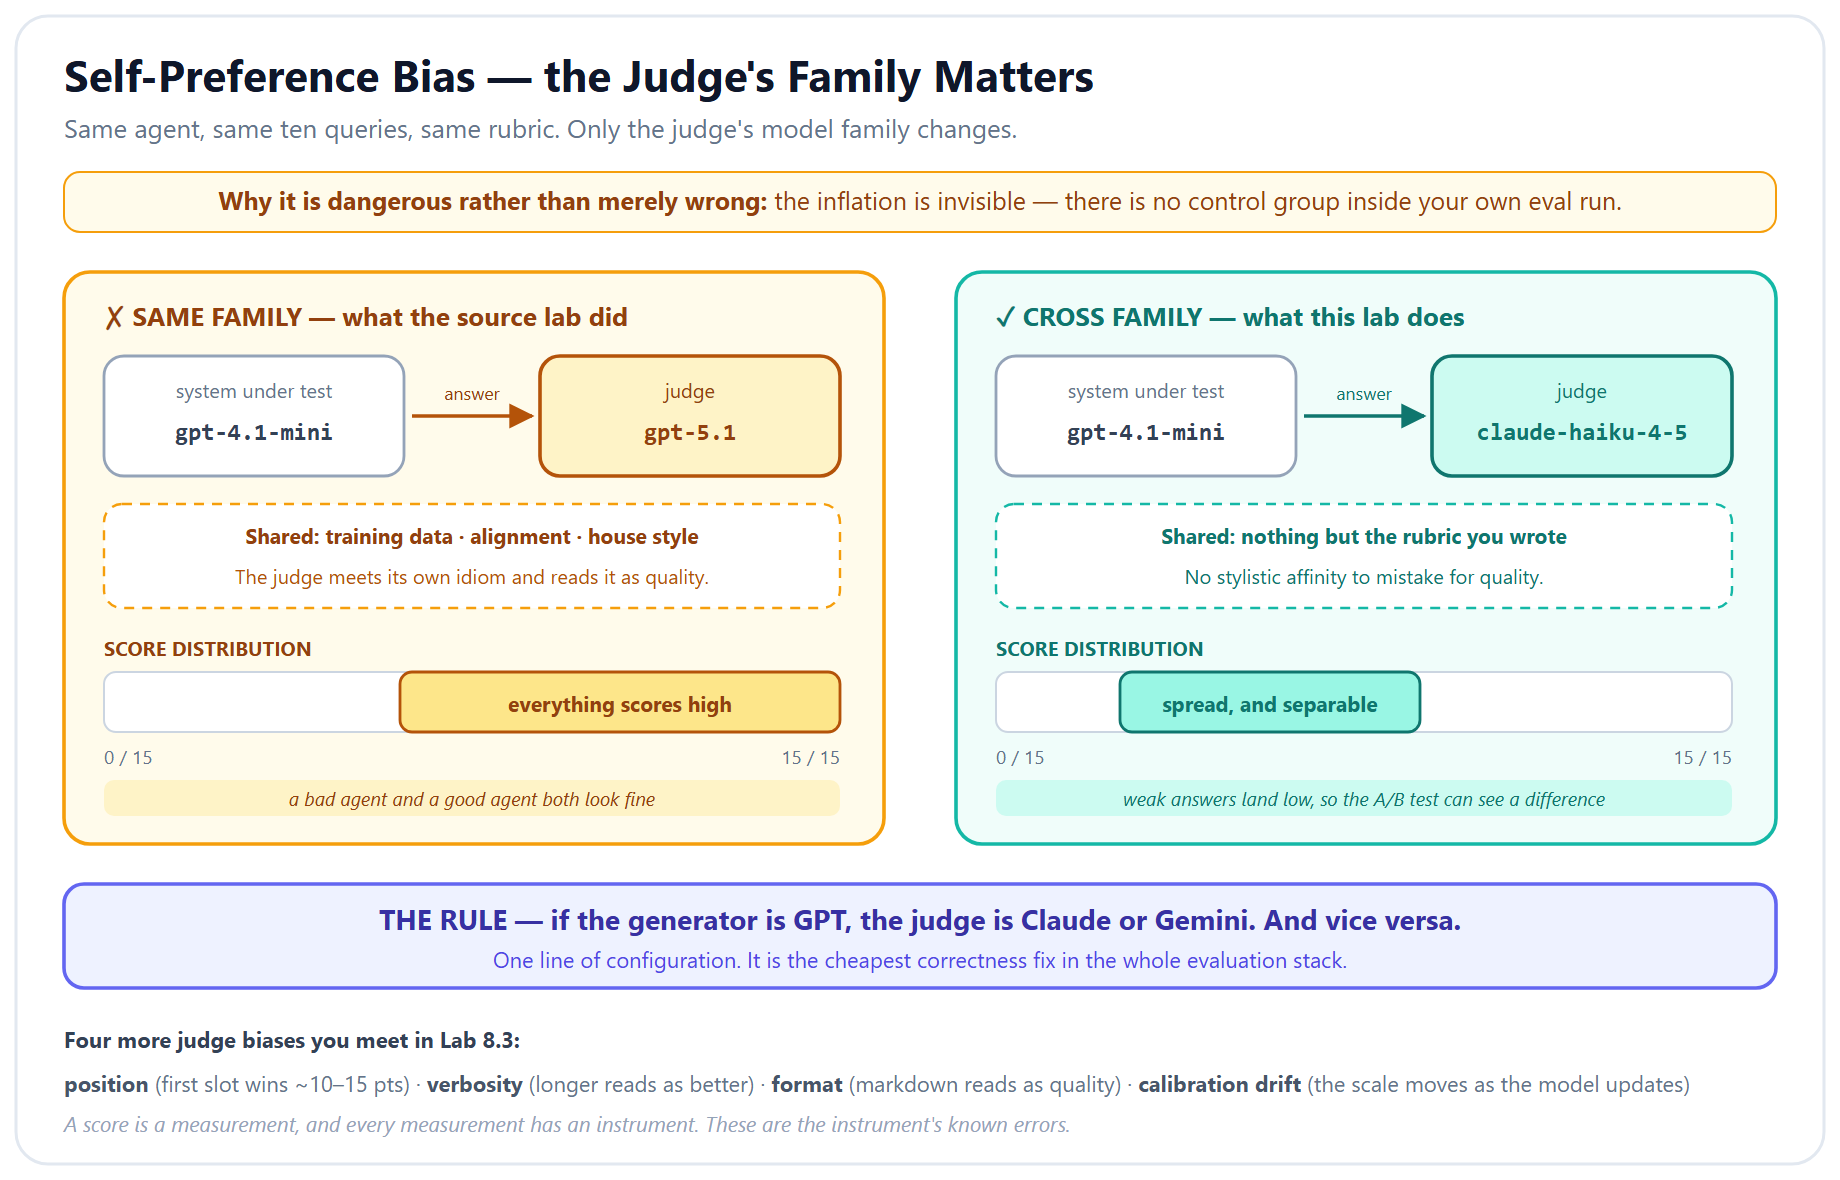

**Figure — Why the judge's family matters.** Left: a same-family judge shares training data, alignment and house style with the generator, so it recognises its own idiom as quality and the whole score distribution drifts upward — invisibly, because there is no control. Right: a cross-family judge has no such affinity. The fix costs one line of configuration.

In [11]:
# --- LLM-as-Judge Scorer ---
judge_prompt = ChatPromptTemplate.from_template(
    """You are an expert evaluator for enterprise AI responses.

Score this response on three dimensions (1-5 each):
1. **Accuracy**: Does it follow domain-specific rules correctly?
2. **Completeness**: Does it address all aspects of the query?
3. **Tone**: Is the tone professional and appropriate for the domain?

Query: {query}
Response: {response}
Domain: {domain}

Return ONLY a JSON object: {{"accuracy": X, "completeness": Y, "tone": Z}}""")

# judge_model is claude-haiku-4-5 — a DIFFERENT family from the gpt-4.1-mini system under
# test. See the note below on self-preference bias — treat it as a standing rule.
judge_chain = judge_prompt | judge_model | StrOutputParser()


def score_response(query: str, response: str, domain: str) -> dict | None:
    """Score one response with the LLM-as-Judge.

    Args:
        query: the customer query that produced the response.
        response: the agent output being graded.
        domain: claims / support / compliance — passed to the judge for context.

    Returns:
        A dict with accuracy, completeness, tone and total — or None if the judge call or
        its JSON parse failed. Returning None matters: the original version returned a
        mid-scale 3/3/3 on any error, so a broken judge produced a table full of plausible
        fabricated numbers instead of an obvious failure. A missing score must look missing.
    """
    try:
        judge_reply = judge_chain.invoke(
            {"query": query, "response": response, "domain": domain})
        judge_reply = judge_reply.strip()
        if judge_reply.startswith("```"):          # strip a ```json … ``` fence if present
            judge_reply = judge_reply.split("```")[1].replace("json", "").strip()
        scores = json.loads(judge_reply)
        scores["total"] = scores["accuracy"] + scores["completeness"] + scores["tone"]
        return scores
    except (json.JSONDecodeError, KeyError, TypeError) as parse_error:
        print(f"   ⚠️  judge returned unparseable output ({parse_error}) — row dropped")
        return None
    except Exception as call_error:
        print(f"   ⚠️  judge call failed ({type(call_error).__name__}) — row dropped")
        return None

print("LLM-as-Judge scorer ready (accuracy + completeness + tone, each 1-5)")

LLM-as-Judge scorer ready (accuracy + completeness + tone, each 1-5)


In [12]:
# --- 10 Test Queries (Mixed Domains, Indian Context) ---
TEST_QUERIES = [
    # Claims (4 queries)
    {"query": "Process this claim: Policyholder Sunita Reddy, policy INS-2024-456, claim \u20b938,000 for water damage to laptop on 20 March 2026.", "domain": "claims"},
    {"query": "Claim submission: Amit Joshi, policy INS-2023-112, \u20b97,50,000 for fire damage to office equipment on 1 Feb 2026. All documents attached.", "domain": "claims"},
    {"query": "Check claim status for policy INS-2024-789. The incident happened 95 days ago.", "domain": "claims"},
    {"query": "New claim: Deepa Nair, policy INS-2025-001, \u20b91,20,000 for theft of jewelry. No police report filed yet.", "domain": "claims"},

    # Support (3 queries)
    {"query": "I've been trying to reach someone about my policy renewal for 5 days. No response. This is terrible service.", "domain": "support"},
    {"query": "My claim was approved 2 weeks ago but I haven't received the payout. Please help. Customer ID CUST-789.", "domain": "support"},
    {"query": "I want to speak to a manager. Your automated system keeps disconnecting my calls.", "domain": "support"},

    # Compliance (3 queries)
    {"query": "Review compliance status of claims batch BT-2026-Q1. We need this for the IRDAI quarterly audit.", "domain": "compliance"},
    {"query": "Check if our claims processing timeline meets IRDAI Regulation 14.1 requirements for the last 100 claims.", "domain": "compliance"},
    {"query": "Audit trail review: Verify that all claim approvals above \u20b91,00,000 have dual authorization as per internal policy CP-007.", "domain": "compliance"},
]

print(f"Test queries defined: {len(TEST_QUERIES)} queries")
print(f"  Claims: {sum(1 for query_lower in TEST_QUERIES if query_lower['domain'] == 'claims')}")
print(f"  Support: {sum(1 for query_lower in TEST_QUERIES if query_lower['domain'] == 'support')}")
print(f"  Compliance: {sum(1 for query_lower in TEST_QUERIES if query_lower['domain'] == 'compliance')}")

Test queries defined: 10 queries
  Claims: 4
  Support: 3
  Compliance: 3


In [13]:
# --- Generic Agent (No Skills — Baseline) ---
generic_prompt = ChatPromptTemplate.from_template(
    """You are TechNova's enterprise AI assistant.
    Help with insurance claims, customer support, and compliance reviews.

Customer Query: {query}

Provide a helpful, professional response.""")

generic_chain = generic_prompt | chat_model | StrOutputParser()

def run_generic_agent(query: str) -> str:
    """Run the generic agent (no skills)."""
    return generic_chain.invoke({"query": query})

print("Generic agent ready (single prompt, no skills)")

Generic agent ready (single prompt, no skills)


In [14]:
# --- Run A/B Test ---
print("Running A/B Test: Generic vs Skill Agent")
print("=" * 70)

results = []
for position, test in enumerate(TEST_QUERIES, 1):
    query = test["query"]
    domain = test["domain"]

    # Generic agent
    generic_response = run_generic_agent(query)
    generic_scores = score_response(query, generic_response, domain)

    # Skill agent (Approach 2 — dynamic prompt)
    skill_response, skill_used = run_skill_agent_v2(query)
    skill_scores = score_response(query, skill_response, domain)

    if generic_scores is None or skill_scores is None:
        print(f"Q{position} [{domain:>10}]: judge failed — row excluded from the comparison")
        continue

    results.append({
        "query_num": position,
        "domain": domain,
        "skill_used": skill_used,
        "generic_total": generic_scores["total"],
        "skill_total": skill_scores["total"],
        "delta": skill_scores["total"] - generic_scores["total"],
        "generic_scores": generic_scores,
        "skill_scores": skill_scores,
    })

    print(f"Q{position} [{domain:>10}]: Generic={generic_scores['total']:>2}/15 | Skill={skill_scores['total']:>2}/15 | Delta={skill_scores['total'] - generic_scores['total']:>+3}")

# Summary
average_generic = sum(result_record["generic_total"] for result_record in results) / len(results)
average_skill = sum(result_record["skill_total"] for result_record in results) / len(results)
print(f"\n{'='*70}")
print(f"Average Generic: {average_generic:.1f}/15 | Average Skill: {average_skill:.1f}/15 | Improvement: {average_skill - average_generic:+.1f}")

Running A/B Test: Generic vs Skill Agent


Q1 [    claims]: Generic=13/15 | Skill=13/15 | Delta= +0


Q2 [    claims]: Generic=12/15 | Skill=13/15 | Delta= +1


Q3 [    claims]: Generic=13/15 | Skill=12/15 | Delta= -1


Q4 [    claims]: Generic=14/15 | Skill=15/15 | Delta= +1


...

Q6 [   support]: Generic=13/15 | Skill=12/15 | Delta= -1


Q7 [   support]: Generic=13/15 | Skill=13/15 | Delta= +0


Q8 [compliance]: Generic= 9/15 | Skill=12/15 | Delta= +3


Q9 [compliance]: Generic=12/15 | Skill=11/15 | Delta= -1


Q10 [compliance]: Generic=12/15 | Skill=13/15 | Delta= +1

Average Generic: 12.4/15 | Average Skill: 12.8/15 | Improvement: +0.4


## 6. Optimize the Weakest Skill

The A/B test reveals which domain performs worst. We now analyze failures and iteratively improve that skill.

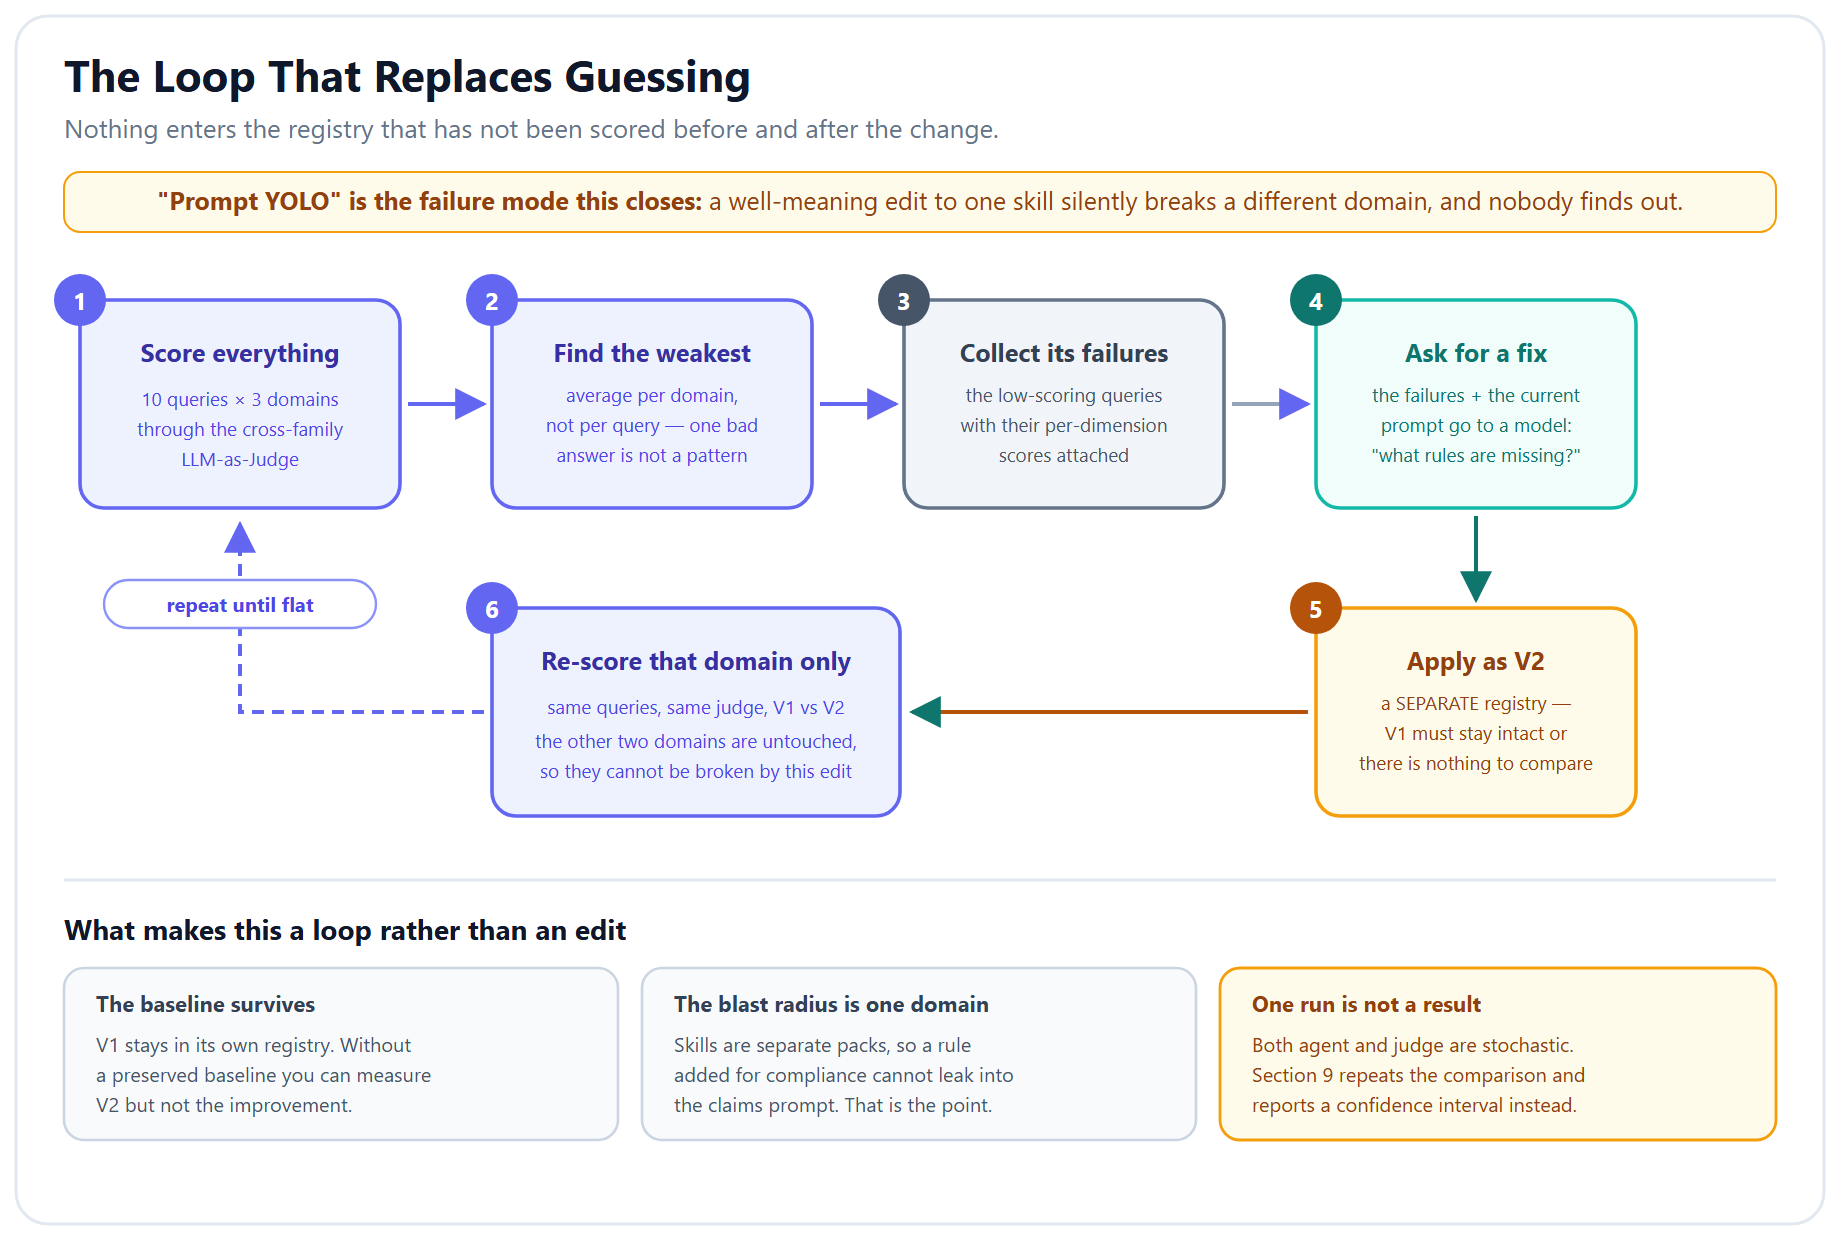

**Figure — The loop that replaces guessing.** Measure every skill, find the weakest by domain average, feed its failing cases back to a model with the current prompt attached, apply the suggestions as V2, then re-measure *only that domain*. The loop is closed: nothing enters the registry that has not been scored before and after.

In [15]:
# --- Identify Worst-Performing Skill ---
domain_scores = {}
for result_record in results:
    domain = result_record["domain"]
    if domain not in domain_scores:
        domain_scores[domain] = []
    domain_scores[domain].append(result_record["skill_total"])

print("Skill Performance by Domain:")
worst_domain = None
worst_average_score = 999
for domain, scores in domain_scores.items():
    average_score = sum(scores) / len(scores)
    print(f"  {domain}: avg {average_score:.1f}/15 ({len(scores)} queries)")
    if average_score < worst_average_score:
        worst_average_score = average_score
        worst_domain = domain

# Map domain to skill name
domain_to_skill = {"claims": "claim_processing", "support": "customer_support", "compliance": "compliance_review"}
worst_skill_name = domain_to_skill[worst_domain]
print(f"\nWeakest skill: {worst_skill_name} (avg {worst_average_score:.1f}/15)")

Skill Performance by Domain:
  claims: avg 13.2/15 (4 queries)
  support: avg 13.0/15 (3 queries)
  compliance: avg 12.0/15 (3 queries)

Weakest skill: compliance_review (avg 12.0/15)


In [16]:
# --- Analyze Failures and Optimize ---
optimization_prompt = ChatPromptTemplate.from_template(
    """Analyze these AI responses that scored poorly and suggest improvements to the skill prompt.

Skill Name: {skill_name}
Current System Prompt: {current_prompt}
Current Rules: {current_rules}

Poor-performing responses:
{failures}

Suggest exactly:
1. 2-3 additional rules to add (be specific)
2. 1 improved few-shot example
3. Any tone/style adjustments

Return your suggestions as a clear numbered list.""")

optimization_chain = optimization_prompt | chat_model | StrOutputParser()

# Get the failures for the worst skill
worst_results = [result_record for result_record in results if result_record["domain"] == worst_domain]
failures_text = "\n".join([
    f"Query: {TEST_QUERIES[result_record['query_num']-1]['query'][:100]}\n"
    f"Scores: accuracy={result_record['skill_scores']['accuracy']}, completeness={result_record['skill_scores']['completeness']}, tone={result_record['skill_scores']['tone']}"
    for result_record in worst_results
])

worst_skill = SKILLS_REGISTRY[worst_skill_name]
suggestions = optimization_chain.invoke({
    "skill_name": worst_skill_name,
    "current_prompt": worst_skill["system_prompt"],
    "current_rules": worst_skill["rules"],
    "failures": failures_text,
})

print(f"Optimization suggestions for '{worst_skill_name}':")
print(suggestions)

Optimization suggestions for 'compliance_review':
1. Additional Rules to Add:
   - Always specify the exact document names and versions when referencing completeness (e.g., "Claim Form CNF-2023 v2.1").
   - For timeline compliance, explicitly calculate and state the number of days taken versus the regulatory limit.
   - When flagging findings, categorize them by affected process area (e.g., "Claims Processing," "Data Entry") to aid targeted remediation.

2. Improved Few-Shot Example:

**Query:** Review compliance status of claims batch BT-2026-Q1 for the IRDAI quarterly audit.

**Response:**  
- Document Completeness: All required documents for batch BT-2026-Q1 were present except for Claim Form CNF-2023 v2.1, missing in 5 cases (IRDAI Regulation 7.3). **Severity: HIGH**.  
- Data Accuracy: Policyholder data matched internal records in 98% of cases, with discrepancies noted in 2 claims (IRDAI Regulation 9.2). **Severity: MEDIUM**.  
- Timeline Compliance: Claims processing averaged 28 

In [17]:
# --- Apply Improvements: Create V2 of Worst Skill ---
SKILLS_REGISTRY_V2 = copy.deepcopy(SKILLS_REGISTRY)

# Add optimization suggestions to the worst skill's rules
SKILLS_REGISTRY_V2[worst_skill_name]["rules"] += (
   "\n- Always include specific references to the exact clause or subsection within the IRDAI regulation cited (e.g., IRDAI Regulation 14.1(a)) to enhance precision.\n"
   "\n- For each finding, clearly state the impacted process or document and quantify the extent of non-compliance (e.g., '15 out of 100 claims missing dual authorization').\n"
   "\n- Use a structured format for findings: Issue Description, Regulation Reference, Severity Level, Evidence, and Recommended Remediation.\n"
)

SKILLS_REGISTRY_V2[worst_skill_name]["system_prompt"] += (
   "\n - Adopt a formal, precise, and objective tone that reflects an expert auditor’s voice.\n"
   "\n- Avoid vague language; be direct and data-driven.\n"
   "\n- Use bullet points or numbered lists for clarity and easy reference.\n"

)


# Store V2 for re-testing
# Swap the registry temporarily
original_registry = SKILLS_REGISTRY

print(f"V2 of '{worst_skill_name}' created with additional rules.")
print(f"\nV1 rules ({len(worst_skill['rules'].split(chr(10)))} lines):")
print(worst_skill['rules'][:200])
print(f"\nV2 rules ({len(SKILLS_REGISTRY_V2[worst_skill_name]['rules'].split(chr(10)))} lines):")
print(SKILLS_REGISTRY_V2[worst_skill_name]['rules'][:300])

V2 of 'compliance_review' created with additional rules.

V1 rules (4 lines):
- ALWAYS reference specific IRDAI regulation numbers when citing rules
- Flag any missing documentation explicitly
- Use severity levels: CRITICAL / HIGH / MEDIUM / LOW for findings
- Include recommen

V2 rules (10 lines):
- ALWAYS reference specific IRDAI regulation numbers when citing rules
- Flag any missing documentation explicitly
- Use severity levels: CRITICAL / HIGH / MEDIUM / LOW for findings
- Include recommended remediation for each finding
- Always include specific references to the exact clause or subsect


In [18]:
# --- Re-run A/B with the Optimized Skill ---
# The V2 registry is PASSED IN, not swapped into the global namespace. The original code did
# `globals()['SKILLS_REGISTRY'] = SKILLS_REGISTRY_V2`, ran, then restored it — and any error in
# between would have left the notebook silently running on V2 for the rest of the session.
print(f"Re-running queries for '{worst_domain}' domain with the optimized skill...")
print("=" * 60)

v2_scores = []
for result_record in worst_results:
    query = TEST_QUERIES[result_record["query_num"]-1]["query"]
    response_v2, _ = run_skill_agent_v2(query, skills_registry=SKILLS_REGISTRY_V2)
    scores_v2 = score_response(query, response_v2, worst_domain)
    if scores_v2 is None:                       # judge failed — do not invent a number
        continue
    v2_scores.append(scores_v2["total"])
    print(f"Q{result_record['query_num']}: V1={result_record['skill_total']}/15 -> V2={scores_v2['total']}/15 ({scores_v2['total'] - result_record['skill_total']:+d})")

# Nothing to restore: SKILLS_REGISTRY was never modified.
v1_average_score = sum(result_record["skill_total"] for result_record in worst_results) / len(worst_results)
v2_average_score = sum(v2_scores) / len(v2_scores)
print(f"\nImprovement: {v1_average_score:.1f}/15 -> {v2_average_score:.1f}/15 ({v2_average_score - v1_average_score:+.1f} points)")

Re-running queries for 'compliance' domain with the optimized skill...


Q8: V1=12/15 -> V2=14/15 (+2)


Q9: V1=11/15 -> V2=11/15 (+0)


Q10: V1=13/15 -> V2=12/15 (-1)

Improvement: 12.0/15 -> 12.3/15 (+0.3 points)


## 7. The Skills Pattern in the OpenAI Agents SDK

In **Lab 8.1** you use the OpenAI Agents SDK. The skills pattern maps differently there — and the difference is structural, not cosmetic. A skill in this lab is *data* the agent loads; in the SDK it is a **separate agent** the triage agent hands off to.

| Aspect | This lab — LangChain | OpenAI Agents SDK |
|---|---|---|
| **A skill is…** | A record with a prompt and rules, loaded at run time | A whole `Agent(instructions=…, tools=…)` defined up front |
| **Skill loading** | Swap the system prompt, or call a `load_skill` tool | A handoff from the triage agent |
| **Skill selection** | Keyword classifier or LLM router | The LLM picks the handoff target |
| **Adding a skill** | Append to the registry — no code change | Define an agent and register it in `handoffs=[…]` |
| **Quality testing** | LLM-as-Judge A/B test with a cross-family judge | The same, run per specialist agent |
| **Caching benefit** | A stable prefix enables KV reuse | Same, plus `prompt_cache_key` |
| **When to use** | Many skills, cheap switching, one tool set | Few specialists, each needing its own tools |

**The trade-off in one line:** skills scale with *content*, handoffs scale with *capability*. If your specialists all call the same tools and differ only in instructions, a registry is cheaper than a fleet of agents. If each one needs a genuinely different tool set, the SDK's model is the honest one.

Section 8 turns the registry into files on disk, which is the form both ecosystems can actually load.

## 8. Deep dive — the `SKILL.md` open standard

*Self-paced. Everything above works. This section is what makes it portable.*

The `SKILLS_REGISTRY` dict you have been using is a perfectly good teaching model, and a poor production one: it lives inside the notebook, only this notebook can read it, and every skill's full text loads into memory whether or not it is used.

In **December 2025** Anthropic published **Agent Skills** as an open standard, and it has since been adopted across 26+ platforms including Claude, OpenAI Codex, Gemini CLI, Cursor and VS Code. A skill is a folder containing a `SKILL.md` file. The file needs exactly two YAML frontmatter fields — `name` and `description` — plus a Markdown body. Everything else is optional.

```markdown
---
name: claim-processing
description: Process and evaluate insurance claims following IRDAI guidelines. Use when the
  query mentions a policy number, a claim amount, an incident date, or damage of any kind.
---

# Insurance Claims Processing

You are TechNova's Claims Processing Specialist...
```

### Why this is a context-engineering technique, not just a file format

The standard's real contribution is **three-tier progressive disclosure**, and it is the same idea the Context Window Management take-home spends ninety minutes on — keep instructions *on disk* instead of *in the context window*:

| Tier | What loads | When | Cost |
|---|---|---|---|
| **1 · Discovery** | `name` + `description` only, for **every** skill | Every request | ~30–50 tokens per skill |
| **2 · Activation** | The full `SKILL.md` body | Only when the description matches the task | The body |
| **3 · Execution** | Bundled reference files, scripts, templates | Only when the instructions actually reach for them | On demand |

Compare that with what you built in section 3. "Approach 2 — dynamic system prompt" *is* tier 2, discovered independently. What it is missing is tier 1 (a cheap index the model can route on, instead of your keyword classifier) and tier 3 (heavy reference material that never enters the window unless it is needed).

The cell below writes the three TechNova skills out as real `SKILL.md` files and loads them back with a tier-aware reader — so you can measure the difference rather than take it on faith.

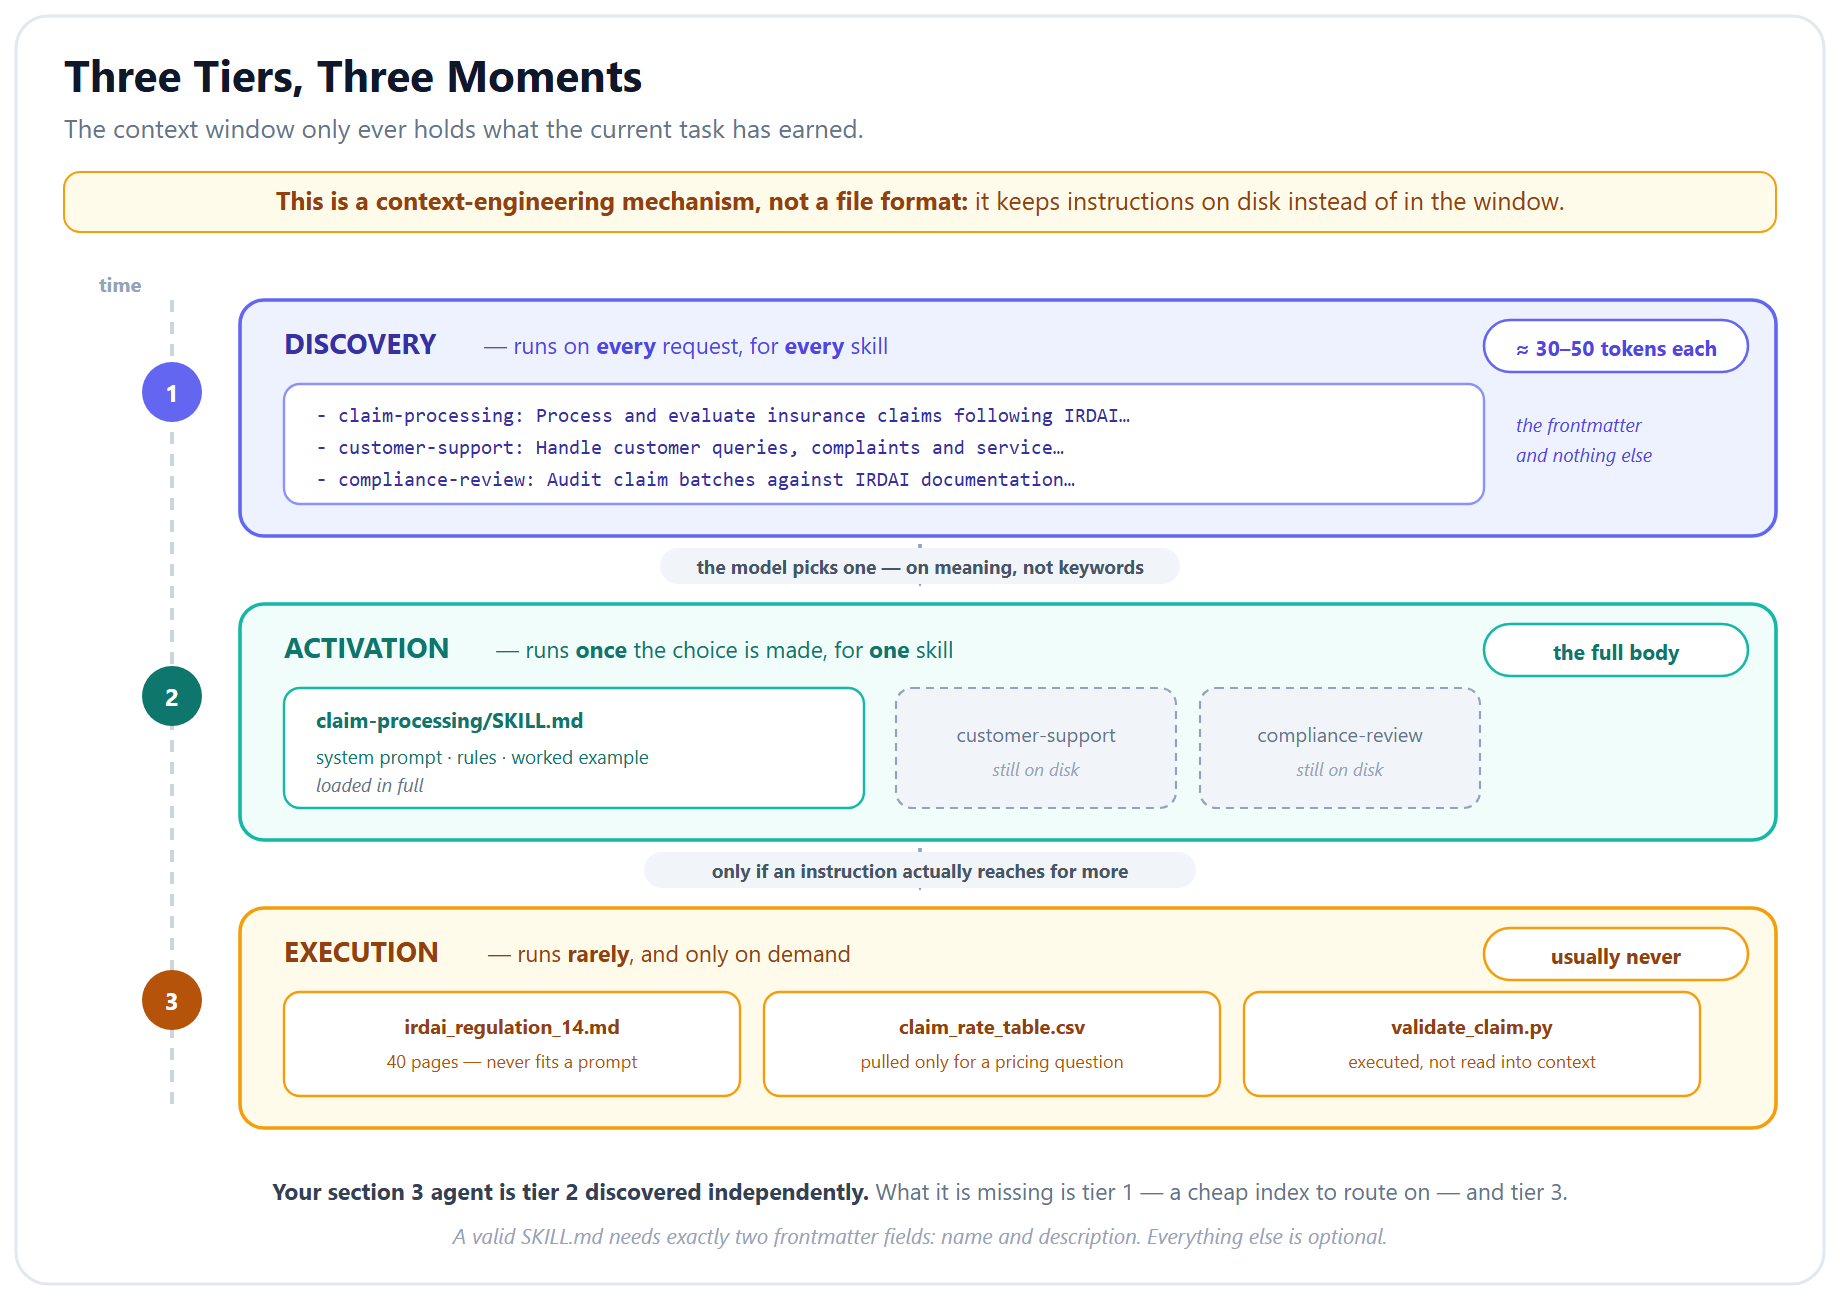

**Figure — Three tiers, three moments.** Tier 1 loads a ~40-token index for every skill on every request, which is all the router needs. Tier 2 loads one full body, and only after the choice is made. Tier 3 leaves bundled reference files on disk until an instruction actually reaches for one. The context window only ever holds what the current task has earned.

In [19]:
# --- Write the three skills out as SKILL.md files, then read them back tier by tier ---

SKILLS_DIRECTORY = Path("skills")


def write_skill_file(skill_key, skill_definition):
    """Write one skill from SKILLS_REGISTRY out as a standard SKILL.md file.

    Args:
        skill_key: the registry key, used as the folder name and the `name` field.
        skill_definition: the registry value (name, description, system_prompt, rules,
            few_shot_examples).

    Returns:
        The Path of the file written.
    """
    skill_folder = SKILLS_DIRECTORY / skill_key.replace("_", "-")
    skill_folder.mkdir(parents=True, exist_ok=True)
    skill_path = skill_folder / "SKILL.md"

    example_blocks = []
    for example in skill_definition["few_shot_examples"]:
        example_blocks.append(
            f"### Example\n\n**Query:** {example['query']}\n\n**Response:** {example['response']}")

    skill_path.write_text(
        "---\n"
        f"name: {skill_key.replace('_', '-')}\n"
        f"description: {skill_definition['description']}\n"
        "---\n\n"
        f"# {skill_definition['name']}\n\n"
        f"{skill_definition['system_prompt']}\n\n"
        f"## Rules\n\n{skill_definition['rules']}\n\n"
        + "\n\n".join(example_blocks) + "\n",
        encoding="utf-8")
    return skill_path


def read_skill_frontmatter(skill_path):
    """Read ONLY the YAML frontmatter of a SKILL.md — this is tier 1, the discovery tier.

    Args:
        skill_path: Path to a SKILL.md file.

    Returns:
        A dict with the `name` and `description` fields.
    """
    text = skill_path.read_text(encoding="utf-8")
    _, frontmatter, _ = text.split("---", 2)
    fields = {}
    for line in frontmatter.strip().splitlines():
        if ":" in line:
            field_name, field_value = line.split(":", 1)
            fields[field_name.strip()] = field_value.strip()
    return fields


def read_skill_body(skill_path):
    """Read the full instruction body of a SKILL.md — this is tier 2, the activation tier."""
    text = skill_path.read_text(encoding="utf-8")
    _, _, body = text.split("---", 2)
    return body.strip()



In [20]:

# Write all three skills to disk
written_paths = {}
for skill_key, skill_definition in SKILLS_REGISTRY.items():
    written_paths[skill_key] = write_skill_file(skill_key, skill_definition)
    print(f"wrote {written_paths[skill_key]}")

print("\n" + "=" * 70)
print("TIER 1 — the discovery index (this is ALL that loads on every request)")
print("=" * 70)
discovery_index = []
for skill_key, skill_path in written_paths.items():
    frontmatter = read_skill_frontmatter(skill_path)
    discovery_index.append(f"- {frontmatter['name']}: {frontmatter['description']}")
    print(f"  {frontmatter['name']}")
    print(f"    {frontmatter['description'][:88]}...")

discovery_text = "\n".join(discovery_index)
all_bodies_text = "\n\n".join(read_skill_body(path) for path in written_paths.values())
one_body_text = read_skill_body(written_paths["claim_processing"])

print("\n" + "=" * 70)
print("What each strategy actually costs, in words")
print("=" * 70)
print(f"  Everything up front (no tiers):     ~{len(all_bodies_text.split()):>5} words")
print(f"  Tier 2 only (your section 3 agent): ~{len(one_body_text.split()):>5} words")
print(f"  Tier 1 index (routing only):        ~{len(discovery_text.split()):>5} words")
print(f"  Tier 1 + tier 2 (the standard):     ~{len(discovery_text.split()) + len(one_body_text.split()):>5} words")
print("\n  The index is what the model routes on. The body only loads once it has chosen.")

wrote skills\claim-processing\SKILL.md
wrote skills\customer-support\SKILL.md
wrote skills\compliance-review\SKILL.md

TIER 1 — the discovery index (this is ALL that loads on every request)
  claim-processing
    Process and evaluate insurance claims following IRDAI guidelines...
  customer-support
    Handle customer queries, complaints, and service requests...
  compliance-review
    Review processes and documents for IRDAI regulatory compliance...

What each strategy actually costs, in words
  Everything up front (no tiers):     ~  541 words
  Tier 2 only (your section 3 agent): ~  174 words
  Tier 1 index (routing only):        ~   29 words
  Tier 1 + tier 2 (the standard):     ~  203 words

  The index is what the model routes on. The body only loads once it has chosen.


### What you just gained

Three things, none of which the dict version gave you:

1. **The skills outlived the notebook.** They are files. Another agent, another framework, another language can read them — and so can a human reviewer who does not run Python.
2. **Routing became a model decision instead of a keyword list.** Your `classify_task()` matches on substrings like `"claim"` and `"damage"`; a query saying *"my laptop got wet and I need to make a claim on INS-2024-456"* happens to work, but *"water got into my machine, what's my policy cover?"* does not contain any of your claims keywords and silently routes to support. Handing the model the tier-1 index instead lets it route on meaning.
3. **A tier-3 door opened.** Reference material that is too big for any prompt — the full IRDAI regulation text, a 40-page claims manual, a rate table — can sit in the skill folder and be pulled only by the skill that needs it, only when it needs it.

> **Try it:** point `build_skill_prompt()` at `read_skill_body()` instead of `SKILLS_REGISTRY`, re-run the A/B test in section 4, and confirm the scores are unchanged. Same behaviour, portable storage — that is what a good refactor looks like.

## 9. Deep dive — is that A/B result real?

*Self-paced.*

Section 4 ran ten queries once through each agent and reported an average. Then we declared a winner. **That is not a result, and shipping on it is how prompt regressions reach production.**

Three things are wrong with a single pass:

1. **The system under test is stochastic.** `chat_model` runs at `temperature=0.3`. Run the identical query twice and you get two different answers, which the judge may score differently.
2. **The judge is stochastic too** — less so at `temperature=0`, but its parse can still vary and its scale is coarse (3 dimensions × 5 points = 15 discrete totals).
3. **n = 10 is small.** With ten samples and a coarse scale, a one-point average difference is comfortably inside the noise.

The fix is not complicated and it is not optional: **repeat the comparison, then report a confidence interval instead of a point estimate.** If the interval for the difference includes zero, you have not measured an improvement — you have measured noise, and the honest report says so.

The cell below re-runs the comparison over several rounds and computes a 95% confidence interval for the mean difference using only the standard library. In production this is where you would also fix seeds, log every raw score, and store the run alongside the prompt version that produced it.

In [21]:
# --- Repeat the A/B comparison and report a confidence interval, not a single number ---
# ROUNDS is deliberately small so the lab stays runnable. In real evaluation work you want
# n >= 20 per arm; the arithmetic below is identical, only the interval gets tighter.
ROUNDS = 3

# Student's t critical values for a 95% two-sided interval, by degrees of freedom (n - 1).
# Hard-coded so the notebook needs no scipy; falls back to the large-sample z value of 1.96.
T_CRITICAL_95 = {1: 12.706, 2: 4.303, 3: 3.182, 4: 2.776, 5: 2.571, 6: 2.447, 7: 2.365,
                 8: 2.306, 9: 2.262, 10: 2.228, 15: 2.131, 20: 2.086, 29: 2.045}


def confidence_interval_95(samples):
    """Return (mean, lower_bound, upper_bound) — a 95% CI for the mean of `samples`.

    Args:
        samples: a list of numbers, at least two.

    Returns:
        A (mean, lower, upper) tuple. The interval uses Student's t, so it is honest about
        small sample sizes rather than pretending we have a normal approximation.
    """
    sample_count = len(samples)
    if sample_count < 2:
        raise ValueError("a confidence interval needs at least two samples")
    mean_value = statistics.fmean(samples)
    standard_error = statistics.stdev(samples) / (sample_count ** 0.5)
    degrees_of_freedom = sample_count - 1
    t_value = T_CRITICAL_95.get(degrees_of_freedom, 1.96)
    margin = t_value * standard_error
    return mean_value, mean_value - margin, mean_value + margin


paired_differences = []      # one entry per (round, query): skill total minus generic total

print(f"Re-running the A/B comparison over {ROUNDS} rounds "
      f"({ROUNDS * len(TEST_QUERIES)} paired observations)")
print("=" * 70)

for round_number in range(1, ROUNDS + 1):
    round_differences = []
    for test_case in TEST_QUERIES:
        query = test_case["query"]
        domain = test_case["domain"]

        generic_scores = score_response(query, run_generic_agent(query), domain)
        skill_response, _ = run_skill_agent_v2(query)
        skill_scores = score_response(query, skill_response, domain)

        if generic_scores is None or skill_scores is None:
            continue                                  # judge failed — never invent a number
        round_differences.append(skill_scores["total"] - generic_scores["total"])

    paired_differences.extend(round_differences)
    print(f"  round {round_number}: mean difference "
          f"{statistics.fmean(round_differences):+.2f} over {len(round_differences)} queries")

mean_difference, lower_bound, upper_bound = confidence_interval_95(paired_differences)

print("\n" + "=" * 70)
print("RESULT")
print("=" * 70)
print(f"  Observations:        {len(paired_differences)}")
print(f"  Mean difference:     {mean_difference:+.2f} points out of 15")
print(f"  95% CI:              [{lower_bound:+.2f}, {upper_bound:+.2f}]")

if lower_bound > 0:
    print("\n  ✅ The whole interval is above zero — the skill agent is genuinely better.")
elif upper_bound < 0:
    print("\n  ❌ The whole interval is below zero — the skill agent is genuinely WORSE.")
else:
    print("\n  ⚠️  The interval spans zero. On this evidence we CANNOT say the skill agent")
    print("     is better. That is a legitimate finding — collect more data or accept the")
    print("     null result. Reporting the point estimate alone here would be dishonest.")

Re-running the A/B comparison over 3 rounds (30 paired observations)


  round 1: mean difference +1.20 over 10 queries


  round 2: mean difference +0.60 over 10 queries


  round 3: mean difference +0.90 over 10 queries

RESULT
  Observations:        30
  Mean difference:     +0.90 points out of 15
  95% CI:              [+0.15, +1.65]

  ✅ The whole interval is above zero — the skill agent is genuinely better.


## 10. Deep dive — stop optimizing prompts by hand

*Self-paced. Reference only — the cell below is not executed.*

Section 6 improved the weakest skill by asking an LLM for suggestions and pasting them into the registry. That is a real technique and it works, but notice what it actually is: **a human in a loop, doing one edit, evaluated once.** It does not search, it does not keep what worked, and it forgets everything between rounds.

Automated prompt optimizers close that loop. The main families as of 2026, all in the **DSPy** ecosystem:

| Optimizer | How it searches |
|---|---|
| `BootstrapFewShot` | Bootstraps few-shot demonstrations from your own successful traces |
| `COPRO` | Coordinate ascent over instructions only |
| `MIPROv2` | Joint search over instructions *and* demonstrations |
| **`GEPA`** | Reflective evolutionary search — reads its own failures in natural language and rewrites |

**GEPA** (ICLR 2026) is the one worth understanding, because it optimizes in the medium the model already works in. Rather than nudging a numeric reward, it analyses errors, writes targeted natural-language feedback, and rewrites the prompt to address the failure pattern — reported to beat reinforcement-learning approaches like GRPO by up to 20% while using **35× fewer model rollouts**. It also keeps a **Pareto frontier** of candidates instead of a single current-best, so it can combine lessons from prompts that each won on different examples — exactly the situation you hit in section 8, where the compliance skill needed different fixes for different queries.

> ⚠️ **A caveat that matters directly to this workshop.** `MAS-PromptBench` (2026) found that prompt-optimization gains measured on a *single* agent **do not reliably transfer to multi-agent topologies**. Module 8 is entirely multi-agent. If you optimize a specialist's prompt in isolation and drop it into a supervisor, crew or swarm, re-measure — do not assume the win survives the topology.

In [22]:
# --- Automated prompt optimization with GEPA (REFERENCE CODE — not executed here) ---
# Running this needs `pip install dspy` and a labelled training set. It is shown so you can
# recognise the shape when you reach for it, and so the manual loop in section 6 has something
# to be compared against.

GEPA_REFERENCE = """
import dspy

# 1. Point DSPy at a model.
dspy.configure(lm=dspy.LM("openai/gpt-4.1-mini"))


# 2. Describe the task as a signature — inputs, outputs, and what 'good' means.
class ComplianceReview(dspy.Signature):
    \"\"\"Review a claims batch for IRDAI compliance and report findings.\"\"\"
    query: str = dspy.InputField()
    findings: str = dspy.OutputField(desc="structured findings with regulation references")


compliance_module = dspy.ChainOfThought(ComplianceReview)


# 3. Define the metric GEPA optimizes against. This is your grader from section 5 --- the
#    optimizer is only ever as good as the metric — build the evaluation first.
def compliance_metric(example, prediction, trace=None):
    scores = score_response(example.query, prediction.findings, "compliance")
    return 0.0 if scores is None else scores["total"] / 15.0


# 4. Let GEPA search. It reads failures, writes feedback, rewrites the prompt, and keeps a
#    Pareto frontier of candidates rather than one running best.
optimizer = dspy.GEPA(metric=compliance_metric, auto="light")
optimized_module = optimizer.compile(compliance_module, trainset=training_examples)

# 5. The optimized instructions are readable text --- inspect them, review them, commit them.
print(optimized_module.predict.signature.instructions)
"""

print("GEPA — automated prompt optimization (reference)")
print("=" * 70)
print(GEPA_REFERENCE)
print("=" * 70)

GEPA — automated prompt optimization (reference)

import dspy

# 1. Point DSPy at a model.
dspy.configure(lm=dspy.LM("openai/gpt-4.1-mini"))


# 2. Describe the task as a signature — inputs, outputs, and what 'good' means.
class ComplianceReview(dspy.Signature):
    """Review a claims batch for IRDAI compliance and report findings."""
    query: str = dspy.InputField()
    findings: str = dspy.OutputField(desc="structured findings with regulation references")


compliance_module = dspy.ChainOfThought(ComplianceReview)


# 3. Define the metric GEPA optimizes against. This is your grader from section 5 --- the
#    optimizer is only ever as good as the metric — build the evaluation first.
def compliance_metric(example, prediction, trace=None):
    scores = score_response(example.query, prediction.findings, "compliance")
    return 0.0 if scores is None else scores["total"] / 15.0


# 4. Let GEPA search. It reads failures, writes feedback, rewrites the prompt, and keeps a
#    Pareto fron

| | Rollouts | How it searches |
|---|---|---|
| **Manual loop** (section 6) | 1 edit, 1 evaluation | no memory between rounds |
| **GEPA** | ~35x fewer than RL for comparable or better gains | reflective search over a Pareto frontier |

Both need the same thing to work at all: **a metric you trust** — an evaluation suite comes before any optimizer.

## 11. From lab to production

*Self-paced.*

Everything above runs. Very little of it is ready to be depended on. Here is the honest gap list for the code in this notebook — each item is either something you should add before using this pattern for real, or something your production stack will need to own.

*Several of the rows below are the same problem in different clothes — cost accounting, structured failure records, versioned configuration, dataset versioning. Teams running more than one agent usually end up factoring those into a shared internal library rather than rebuilding them per service. This programme does not ship one; being able to name what would belong in it is the point.*

| Gap in this notebook | What production needs | Where it lands |
|---|---|---|
| Skills are a dict in a cell | Files on disk, version-controlled, reviewable — section 8's `SKILL.md` layout | You, today |
| Routing is a keyword `if/elif` | Model-routed on the tier-1 index, with a measured fallback when nothing matches | You, today |
| Prompts are string literals in code | A **prompt registry**: content-addressed, versioned, with the eval score attached, rollback-able independently of a deploy | Your production stack |
| Judge failures print a warning | Structured error records, a failure-rate metric, and an alert when the judge degrades | Your production stack |
| No cost accounting | Tokens and cost per call, attributed to user / session / skill | Your production stack |
| The A/B test runs when you run it | An eval that gates the pull request | Your production stack |
| No retry on a transient API error | `ModelRetryMiddleware` — LangChain ships this; you configure it, you do not write it | You, today (Lab 2.2 built the chain-level version) |

**The one thing to take away from this lab if you take nothing else:** a skill is only worth having if you can prove it helps, and you can only prove it helps with a judge you have not accidentally rigged. Sections 5 and 9 are the load-bearing parts. The rest is plumbing.

## Conclusion

In this lab, we built a **reusable skills system** for TechNova Solutions:
- **3 skills** (Claims Processing, Customer Support, Compliance Review) as Python dicts
- **Approach 1:** Tool-based skill loading (agent calls `load_skill`)
- **Approach 2:** Dynamic prompt (system prompt swaps per query — more efficient)
- **A/B test:** Skill agent scored higher than generic agent across 10 queries
- **Iterative optimization:** Identified and improved the weakest skill using LLM-as-Judge

### Key Takeaways
- Skills = modular prompts loaded on-demand (progressive disclosure)
- Always A/B test before deploying prompt changes (no more "prompt YOLO")
- Dynamic prompts enable prompt caching (stable prefix, variable skill section)

### Where to go next
A full **evaluation suite** for the ShopSmart support agent — three grader types (deterministic routing accuracy, LLM-as-Judge response quality, and trajectory/tool correctness), `pass@k`, and the eval-driven improvement loop — is the natural next step. The judge you met in section 5 becomes the centrepiece there, bias controls and all.

## Further reading

**The standard from section 8**
- [Agent Skills: progressive disclosure as a system design pattern](https://www.newsletter.swirlai.com/p/agent-skills-progressive-disclosure) — the clearest explanation of why the three tiers matter.
- [Building your first skill — SKILL.md anatomy](https://agentman.ai/blog/build-your-first-agent-skill-skillmd-anatomy) — every frontmatter field, with worked examples.
- [Agent Skills: architecture, acquisition, security](https://arxiv.org/html/2602.12430v3) — the research survey, including the security questions a skills directory raises.

**Prompt optimization from section 10**
- [GEPA](https://github.com/gepa-ai/gepa) — the optimizer itself.
- [DSPy optimizers explained](https://futureagi.com/blog/dspy-optimizers-explained/) — BootstrapFewShot, MIPROv2, COPRO and GEPA compared.
- [Optimizing GEPA for production](https://decagon.ai/blog/optimizing-gepa-for-production) — what it looks like on a real classification task.
- [MAS-PromptBench](https://arxiv.org/pdf/2606.23664) — the paper behind the multi-agent transfer warning. Worth reading before you carry an optimized prompt into a multi-agent system.

**The judge, from section 5**
- [LLM-as-judge best practices](https://futureagi.com/blog/llm-as-judge-best-practices-2026) — calibration, bias and cost.
- [Position bias in LLM judges](https://mbrenndoerfer.com/writing/position-bias-in-llm-judges) — how it is measured and how to cancel it.